In [27]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

In [28]:
tf.__version__

'2.21.0'

In [29]:
#pip install tensorflow-gpu==1.14

In [30]:
keras.backend.backend()

'tensorflow'

In [31]:
fm = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fm.load_data()

In [32]:
# 60,000 images with a pixel density of 28 x 28
X_train.shape

(60000, 28, 28)

In [33]:
# 10,000 images with a pixel density of 28 x 28
X_test.shape

(10000, 28, 28)

In [34]:
# 1st image is displayed as bits with a pixel density of 28 x 28
# According to the RGB color scheme, ranging from 0 - 255
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [35]:
# class , respective image 0 is belonging into is......
y_train[0]

np.uint8(9)

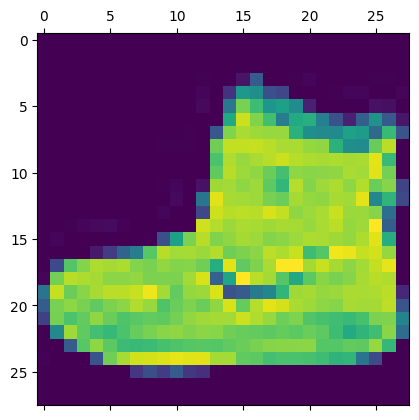

In [36]:
plt.matshow(X_train[0])

In [37]:
# normalize all data, dividing by 255. Then all values will range in between 0 - 1.
# this will facilitate the learning process.
X_train = X_train/255
# Add channel dimension for CNN (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_train.shape


(60000, 28, 28, 1)

In [38]:
X_test = X_test/255
# Add channel dimension for CNN (10000, 28, 28, 1)
X_test = np.expand_dims(X_test, -1)
X_test.shape


(10000, 28, 28, 1)

In [39]:
# Commencing to create the Convolutional Neural Network (CNN) Model
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# creating a Sequential model
model = Sequential()
# input layer representing 28x28 grayscale images
model.add(Input(shape=(28, 28, 1)))
# First convolution and pooling block
model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
# Second convolution and pooling block
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))  # Regularize feature maps
# Flatten the output and feed to dense layer
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))   # Increased dropout to reduce dense layer overfitting
# Output layer for 10-class multi-class classification
model.add(Dense(10, activation="softmax"))


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# configuring the back-propergation process.
# hence this is multi-class, loss function should be spare_categorical.
# adam optimizer controls the back-propergation process.
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [42]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7706 - loss: 0.6372 - val_accuracy: 0.8530 - val_loss: 0.3911
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8392 - loss: 0.4448 - val_accuracy: 0.8715 - val_loss: 0.3433
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8592 - loss: 0.3939 - val_accuracy: 0.8840 - val_loss: 0.3161
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8694 - loss: 0.3625 - val_accuracy: 0.8900 - val_loss: 0.3013
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8791 - loss: 0.3389 - val_accuracy: 0.8974 - val_loss: 0.2870
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8842 - loss: 0.3226 - val_accuracy: 0.8978 - val_loss: 0.2754
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8881 - loss: 0.3107 - val_accuracy: 0.8937 - val_loss: 0.2831
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8918 - loss: 0.3006 - 

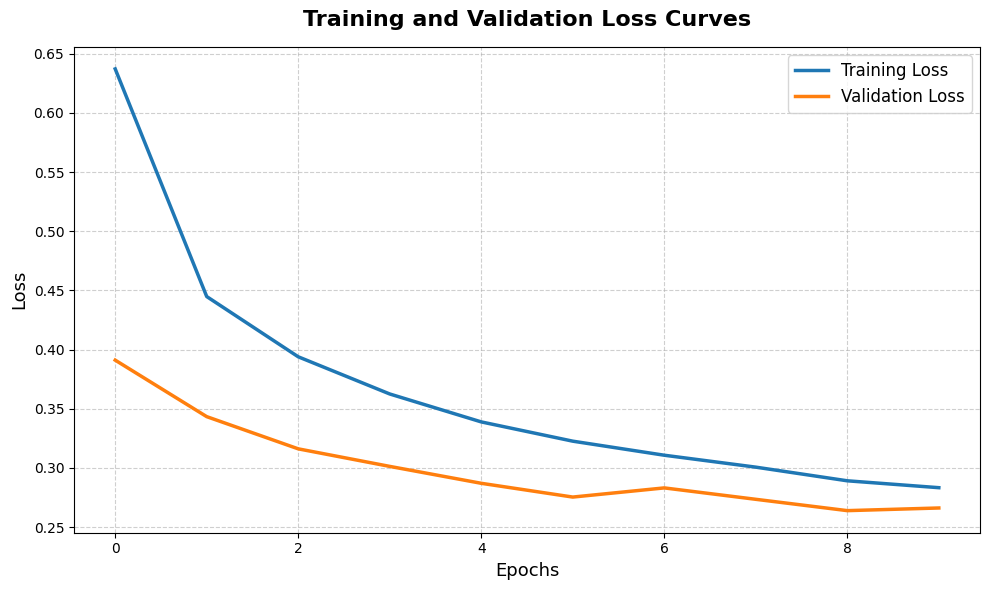

In [43]:
# Plotting the training and validation loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Loss Curves', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [44]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9029 - loss: 0.2661


[0.2661399245262146, 0.902899980545044]

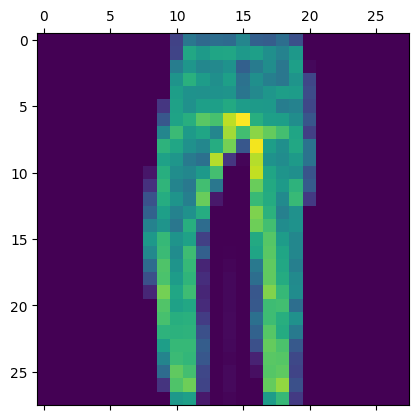

In [45]:
# visualize the item to be predicted
plt.matshow(X_test[8252].squeeze())

In [46]:
# does the prediction for all test items
yp = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step


In [47]:
# display only the prediction of the 1250th item
yp[8252]

array([5.7932894e-08, 1.0000000e+00, 1.9076803e-10, 6.7450241e-09,
       7.9228912e-10, 7.7112423e-14, 4.7061284e-09, 1.3672888e-19,
       7.0778411e-10, 1.1797563e-19], dtype=float32)

In [48]:
# derive the prediction % with the maximum confidence
np.argmax(yp[8252])

np.int64(1)

In [49]:
class_labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [50]:
# derive the prediction outcome
class_labels[np.argmax(yp[8252])]

'Trouser'

In [51]:
# what is actually 1250th item
y_test[8252]

np.uint8(1)

In [52]:
# actually 1250th item
class_labels[1]

'Trouser'